<a href="https://colab.research.google.com/github/dellae09/academic-performance-clustering-kmeans-sa/blob/main/03_Prapemrosesan_Nilai_Ujian_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
# Tujuan:
# (1) Profil data awal (RAW) — lengkap + diagram missing (UTS, UAS, gabungan)
# (2) Standarisasi kolom + parsing nilai
# (3) Validasi & pelaporan NPM bermasalah (tanpa hapus otomatis) + auto-fix FIXABLE
# (4) Deduplikasi resmi (untuk ujian: NPM+Nama+Kelas+Nilai_Raw+Jenis_Ujian)
# (5) Pemetaan MK -> Soal teoritis -> penyetaraan 0–100
# (6) Simpan clean long (UTS+UAS real) + agregasi final adil (per MK lalu mean antar MK)
# ============================================================

***Cell 1 — Mount Drive***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


***[CELL 02] Import Library + Path Output***

In [ ]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

IN_UTS = "/content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Mentah/Nilai UTS ALL ( Dari Database).csv"
IN_UAS = "/content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Mentah/Nilai Uas ALL (Dari Database).csv"

OUT_DIR = "/content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Ujian"
os.makedirs(OUT_DIR, exist_ok=True)

# output jejak proses
OUT_RAW_PROFILE_UTS   = os.path.join(OUT_DIR, "ujian_uts_raw_profile_2025.csv")
OUT_RAW_PROFILE_UAS   = os.path.join(OUT_DIR, "ujian_uas_raw_profile_2025.csv")
OUT_RAW_PROFILE_ALL   = os.path.join(OUT_DIR, "ujian_raw_gabungan_profile_2025.csv")

OUT_STAGE1_STD        = os.path.join(OUT_DIR, "ujian_stage1_standardized_2025.csv")
OUT_STAGE2_DEDUP      = os.path.join(OUT_DIR, "ujian_stage2_deduplicated_2025.csv")
OUT_LONG_CLEAN        = os.path.join(OUT_DIR, "ujian_long_clean_2025.csv")

OUT_BAD_NPM           = os.path.join(OUT_DIR, "report_ujian_npm_bermasalah_2025.csv")
OUT_BAD_MK            = os.path.join(OUT_DIR, "report_ujian_mk_tidak_terpetakan_2025.csv")
OUT_BAD_SCALE         = os.path.join(OUT_DIR, "report_ujian_penyetaraan_bermasalah_2025.csv")

OUT_FINAL_WIDE         = os.path.join(OUT_DIR, "ujian_final_wide_1npm_1nilai_2025.csv")


STRICT_NPM = True   # stop kalau masih ada INVALID setelah auto-fix
STRICT_MK  = False  # MK unmapped tidak stop, tapi dilaporkan

***[CELL 03] Tabel Soal Teoritis (MK → jumlah soal)***

In [ ]:
MK_STANDARDS = [
    "komputer dan pemrograman",
    "pemrograman berorientasi objek",
    "sistem basis data",
    "statistika dan probabilitas",
    "intelligent tutoring system",
    "konsep basis data",
    "desain basis data",
]

MK_ALIASES = {
    "kdp": "komputer dan pemrograman",
    "komdat": "komputer dan pemrograman",
    "pbo": "pemrograman berorientasi objek",
    "oop": "pemrograman berorientasi objek",
    "sbd": "sistem basis data",
    "statprob": "statistika dan probabilitas",
    "statistika": "statistika dan probabilitas",
    "probabilitas": "statistika dan probabilitas",
    "its": "intelligent tutoring system",
    "inteliigent": "intelligent tutoring system",
    "inteliigent tutoring system": "intelligent tutoring system",
    "intelligent tutoring": "intelligent tutoring system",
    "kbd": "konsep basis data",
    "dbd": "desain basis data",
}

***[CELL 04] Utilitas Umum (Read CSV, Normalisasi, Parsing Angka)***

In [ ]:
def read_csv_safely(path: str) -> pd.DataFrame:
    seps = [";", ",", "\t", "|"]
    last_err = None
    for sep in seps:
        try:
            df = pd.read_csv(path, dtype=str, sep=sep, engine="python")
            if df.shape[1] > 1:
                return df
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Gagal membaca CSV: {path}. Error terakhir: {last_err}")

def normalize_text(x: str) -> str:
    if pd.isna(x):
        return ""
    return re.sub(r"\s+", " ", str(x)).strip()

def to_numeric_safe(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False), errors="coerce")

def profile_raw(df: pd.DataFrame, label: str, top_n: int = 15) -> pd.DataFrame:
    print("="*110)
    print(f"INFORMASI AWAL DATASET (RAW) — {label}")
    print("="*110)
    print("Ukuran data (baris, kolom):", df.shape)

    print("\nNama kolom (urut asli):")
    for i, c in enumerate(df.columns, 1):
        print(f"{i:02d}. {c}")

    print("\nTipe data (dtype) per kolom:")
    display(df.dtypes.to_frame("dtype").reset_index().rename(columns={"index":"Kolom"}))

    print("\nPreview 10 baris pertama:")
    display(df.head(10))

    prof = pd.DataFrame({
        "Kolom": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "Missing_Count": [int(df[c].isna().sum()) for c in df.columns],
        "Missing_Rate": [float(df[c].isna().mean()) for c in df.columns],
        "Unique_Count": [int(df[c].nunique(dropna=True)) for c in df.columns],
        "Contoh_Nilai": [
            df[c].dropna().astype(str).head(1).iloc[0] if df[c].dropna().shape[0] else ""
            for c in df.columns
        ],
    }).sort_values(["Missing_Rate","Unique_Count"], ascending=[False, False])

    print("\nTabel profil RAW (missing, unik, contoh):")
    display(prof)

    miss = df.isna().mean().sort_values(ascending=False).head(top_n)
    plt.figure()
    miss.plot(kind="bar")
    plt.title(f"Missing Rate Top {top_n} — RAW ({label})")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()

    return prof

***[CELL 05] Load RAW Dataset***

In [ ]:
df_uts_raw = read_csv_safely(IN_UTS)
df_uas_raw = read_csv_safely(IN_UAS)
print("RAW loaded: UTS & UAS")


RAW loaded: UTS & UAS


***CELL 06 — Profil RAW UTS***

INFORMASI AWAL DATASET (RAW) — UTS
Ukuran data (baris, kolom): (382, 4)

Nama kolom (urut asli):
01. NPM
02. nama_lengkap
03. nama_kelas
04. nilai_uts

Tipe data (dtype) per kolom:


,Kolom,dtype
0,NPM,object
1,nama_lengkap,object
2,nama_kelas,object
3,nilai_uts,object



Preview 10 baris pertama:


,NPM,nama_lengkap,nama_kelas,nilai_uts
0,G1F022077,Ahmad Afif Nurdiantoro,Desain Basis Data,55.17
1,G1F023045,Ahmad Al Fikri,Desain Basis Data,51.72
2,G1F022005,Ahmad Fadhila,Desain Basis Data,62.07
3,G1F023005,AMMI SUMIYANA,Desain Basis Data,37.93
4,G1F023043,Anas Thasiya Astuti,Desain Basis Data,55.17
5,G1F023016,Andini Istiqomah,Desain Basis Data,75.86
6,G1F023047,Annisa Rizky Maulida,Desain Basis Data,75.86
7,G1F023017,Antanur Mantoyasiin,Desain Basis Data,51.72
8,G1F0230022,arinta sekar jannati,Desain Basis Data,37.93
9,G1F023054,Bela Rizki Agustin,Desain Basis Data,72.41



Tabel profil RAW (missing, unik, contoh):


,Kolom,dtype,Missing_Count,Missing_Rate,Unique_Count,Contoh_Nilai
0,NPM,object,0,0.0,168,G1F022077
1,nama_lengkap,object,0,0.0,168,Ahmad Afif Nurdiantoro
3,nilai_uts,object,0,0.0,81,55.17
2,nama_kelas,object,0,0.0,6,Desain Basis Data


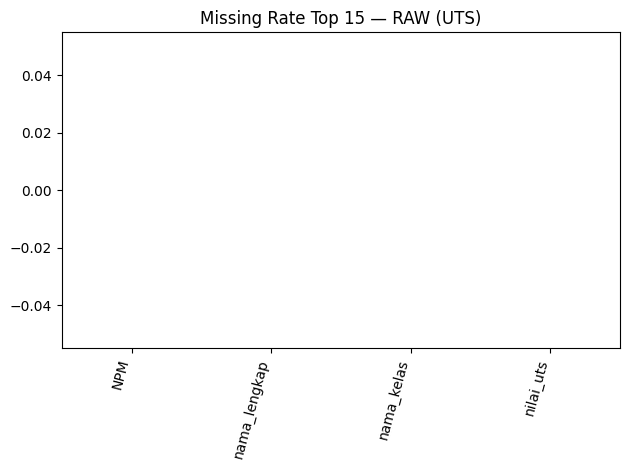

Profil RAW UTS tersimpan: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Ujian/ujian_uts_raw_profile_2025.csv


In [ ]:
prof_uts = profile_raw(df_uts_raw, "UTS")
prof_uts.to_csv(OUT_RAW_PROFILE_UTS, index=False)
print("Profil RAW UTS tersimpan:", OUT_RAW_PROFILE_UTS)

***CELL 07 — Profil RAW UAS***

INFORMASI AWAL DATASET (RAW) — UAS
Ukuran data (baris, kolom): (90, 4)

Nama kolom (urut asli):
01. NPM
02. nama_lengkap
03. nama_kelas
04. nilai_uas

Tipe data (dtype) per kolom:


,Kolom,dtype
0,NPM,object
1,nama_lengkap,object
2,nama_kelas,object
3,nilai_uas,object



Preview 10 baris pertama:


,NPM,nama_lengkap,nama_kelas,nilai_uas
0,G1F022078,Abel Restu Putra Pratama,2025 Komputer dan Pemrograman,44.00
1,G1F025066,Abi Mayu Priamitra,2025 Komputer dan Pemrograman,48.00
2,G1F025051,Abiemayu Herlaputra,2025 Komputer dan Pemrograman,36.00
3,G1F025071,Adam Fakhry Sanjaya,2025 Komputer dan Pemrograman,60.00
4,G1F025017,Ahmad Nadhif Arsyalan,2025 Komputer dan Pemrograman,68.00
5,G1F025046,Ahmad Rafi Pratiza,2025 Komputer dan Pemrograman,40.00
6,G1F025019,Aida Silva Mahyudin,2025 Komputer dan Pemrograman,48.00
7,G1F025012,Aisyah Dewi,2025 Komputer dan Pemrograman,40.00
8,G1F025005,Amanda Pratiwi,2025 Komputer dan Pemrograman,44.00
9,G1F0250023,Ananda Mikola,2025 Komputer dan Pemrograman,44.00



Tabel profil RAW (missing, unik, contoh):


,Kolom,dtype,Missing_Count,Missing_Rate,Unique_Count,Contoh_Nilai
0,NPM,object,0,0.0,90,G1F022078
1,nama_lengkap,object,0,0.0,90,Abel Restu Putra Pratama
3,nilai_uas,object,0,0.0,15,44.00
2,nama_kelas,object,0,0.0,1,2025 Komputer dan Pemrograman


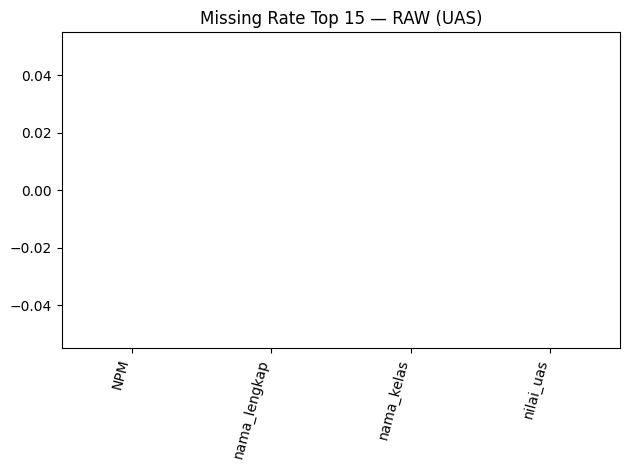

Profil RAW UAS tersimpan: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Ujian/ujian_uas_raw_profile_2025.csv


In [ ]:
prof_uas = profile_raw(df_uas_raw, "UAS")
prof_uas.to_csv(OUT_RAW_PROFILE_UAS, index=False)
print("Profil RAW UAS tersimpan:", OUT_RAW_PROFILE_UAS)

***CELL 08 — Gabungkan RAW (UTS+UAS) + Profil RAW Gabungan (wajib + diagram)***

INFORMASI AWAL DATASET (RAW) — GABUNGAN (UTS+UAS)
Ukuran data (baris, kolom): (472, 6)

Nama kolom (urut asli):
01. NPM
02. nama_lengkap
03. nama_kelas
04. nilai_uts
05. Jenis_Ujian
06. nilai_uas

Tipe data (dtype) per kolom:


,Kolom,dtype
0,NPM,object
1,nama_lengkap,object
2,nama_kelas,object
3,nilai_uts,object
4,Jenis_Ujian,object
5,nilai_uas,object



Preview 10 baris pertama:


,NPM,nama_lengkap,nama_kelas,nilai_uts,Jenis_Ujian,nilai_uas
0,G1F022077,Ahmad Afif Nurdiantoro,Desain Basis Data,55.17,UTS,NaN
1,G1F023045,Ahmad Al Fikri,Desain Basis Data,51.72,UTS,NaN
2,G1F022005,Ahmad Fadhila,Desain Basis Data,62.07,UTS,NaN
3,G1F023005,AMMI SUMIYANA,Desain Basis Data,37.93,UTS,NaN
4,G1F023043,Anas Thasiya Astuti,Desain Basis Data,55.17,UTS,NaN
5,G1F023016,Andini Istiqomah,Desain Basis Data,75.86,UTS,NaN
6,G1F023047,Annisa Rizky Maulida,Desain Basis Data,75.86,UTS,NaN
7,G1F023017,Antanur Mantoyasiin,Desain Basis Data,51.72,UTS,NaN
8,G1F0230022,arinta sekar jannati,Desain Basis Data,37.93,UTS,NaN
9,G1F023054,Bela Rizki Agustin,Desain Basis Data,72.41,UTS,NaN



Tabel profil RAW (missing, unik, contoh):


,Kolom,dtype,Missing_Count,Missing_Rate,Unique_Count,Contoh_Nilai
5,nilai_uas,object,382,0.809322,15,44.00
3,nilai_uts,object,90,0.190678,81,55.17
0,NPM,object,0,0.000000,256,G1F022077
1,nama_lengkap,object,0,0.000000,256,Ahmad Afif Nurdiantoro
2,nama_kelas,object,0,0.000000,7,Desain Basis Data
4,Jenis_Ujian,object,0,0.000000,2,UTS


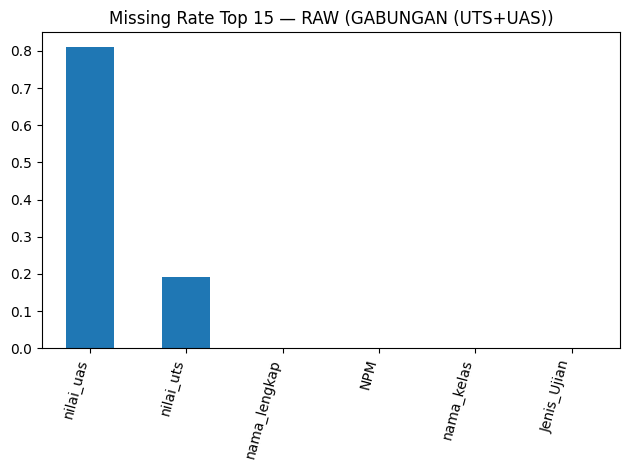

Profil RAW Gabungan tersimpan: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Ujian/ujian_raw_gabungan_profile_2025.csv


In [ ]:
df_uts_raw2 = df_uts_raw.copy()
df_uas_raw2 = df_uas_raw.copy()

df_uts_raw2["Jenis_Ujian"] = "UTS"
df_uas_raw2["Jenis_Ujian"] = "UAS"

df_raw_all = pd.concat([df_uts_raw2, df_uas_raw2], ignore_index=True)
prof_all = profile_raw(df_raw_all, "GABUNGAN (UTS+UAS)")

prof_all.to_csv(OUT_RAW_PROFILE_ALL, index=False)
print("Profil RAW Gabungan tersimpan:", OUT_RAW_PROFILE_ALL)

# ***PREPROCESSING***

***[CELL 09] Fungsi Standarisasi Kolom***

In [ ]:
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = {c: normalize_text(c).lower() for c in df.columns}
    df = df.rename(columns=cols).copy()

    npm_cols   = ["npm", "nim", "id_mahasiswa", "id"]
    nama_cols  = ["nama", "nama_lengkap", "nama mahasiswa", "namalengkap"]
    kelas_cols = ["kelas", "nama_kelas", "class", "kelas_name"]

    nilai_cols = [
        "nilai_uts","uts","nilai_uas","uas","nilai_ujian","ujian",
        "nilai","score","skor"
    ]
    mk_cols    = ["mata_kuliah", "matakuliah", "mk", "nama_mk", "course", "mata kuliah"]

    def pick(existing, candidates):
        for c in candidates:
            if c in existing:
                return c
        return None

    existing = set(df.columns)
    c_npm   = pick(existing, npm_cols)
    c_nama  = pick(existing, nama_cols)
    c_kelas = pick(existing, kelas_cols)
    c_nilai = pick(existing, nilai_cols)
    c_mk    = pick(existing, mk_cols)

    rename_map = {}
    if c_npm:   rename_map[c_npm]   = "NPM"
    if c_nama:  rename_map[c_nama]  = "Nama"
    if c_kelas: rename_map[c_kelas] = "Kelas"
    if c_nilai: rename_map[c_nilai] = "Nilai_Raw"
    if c_mk:    rename_map[c_mk]    = "Mata_Kuliah"

    df = df.rename(columns=rename_map)

    required = ["NPM","Nama","Kelas","Nilai_Raw"]
    missing_req = [c for c in required if c not in df.columns]
    if missing_req:
        raise ValueError(f"Kolom wajib tidak ditemukan: {missing_req}. Kolom tersedia: {list(df.columns)}")

    if "Mata_Kuliah" not in df.columns:
        df["Mata_Kuliah"] = ""

    if "Jenis_Ujian" not in df.columns:
        df["Jenis_Ujian"] = ""

    return df

***CELL 10] Standarisasi Kolom + Parsing Nilai (Stage 1)***

In [ ]:
df = standardize_columns(df_raw_all)

for c in ["NPM","Nama","Kelas","Mata_Kuliah","Nilai_Raw","Jenis_Ujian"]:
    df[c] = df[c].astype(str).str.strip()

df["Nilai_Raw_Num"] = to_numeric_safe(df["Nilai_Raw"])

print("="*110)
print("HASIL STAGE 1 — UJIAN (UTS+UAS) — Setelah Standarisasi + Parsing")
print("="*110)
print("Ukuran:", df.shape)
print("Kolom:", list(df.columns))
display(df.head(10))

stage1_profile = pd.DataFrame({
    "Kolom": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "Missing_Count": [int(df[c].isna().sum()) for c in df.columns],
    "Missing_Rate": [float(df[c].isna().mean()) for c in df.columns],
    "Unique_Count": [int(df[c].nunique(dropna=True)) for c in df.columns],
}).sort_values("Missing_Rate", ascending=False)
display(stage1_profile)

print("="*110)
print("SEBELUM SAVE STAGE 1 — UJIAN")
print("="*110)
print("Ukuran:", df.shape)
display(df.head(5))

df.to_csv(OUT_STAGE1_STD, index=False)
print("Stage 1 tersimpan:", OUT_STAGE1_STD)

HASIL STAGE 1 — UJIAN (UTS+UAS) — Setelah Standarisasi + Parsing
Ukuran: (472, 9)
Kolom: ['NPM', 'Nama', 'Kelas', 'Nilai_Raw', 'jenis_ujian', 'nilai_uas', 'Mata_Kuliah', 'Jenis_Ujian', 'Nilai_Raw_Num']


,NPM,Nama,Kelas,Nilai_Raw,jenis_ujian,nilai_uas,Mata_Kuliah,Jenis_Ujian,Nilai_Raw_Num
0,G1F022077,Ahmad Afif Nurdiantoro,Desain Basis Data,55.17,UTS,NaN,,,55.17
1,G1F023045,Ahmad Al Fikri,Desain Basis Data,51.72,UTS,NaN,,,51.72
2,G1F022005,Ahmad Fadhila,Desain Basis Data,62.07,UTS,NaN,,,62.07
3,G1F023005,AMMI SUMIYANA,Desain Basis Data,37.93,UTS,NaN,,,37.93
4,G1F023043,Anas Thasiya Astuti,Desain Basis Data,55.17,UTS,NaN,,,55.17
5,G1F023016,Andini Istiqomah,Desain Basis Data,75.86,UTS,NaN,,,75.86
6,G1F023047,Annisa Rizky Maulida,Desain Basis Data,75.86,UTS,NaN,,,75.86
7,G1F023017,Antanur Mantoyasiin,Desain Basis Data,51.72,UTS,NaN,,,51.72
8,G1F0230022,arinta sekar jannati,Desain Basis Data,37.93,UTS,NaN,,,37.93
9,G1F023054,Bela Rizki Agustin,Desain Basis Data,72.41,UTS,NaN,,,72.41


,Kolom,dtype,Missing_Count,Missing_Rate,Unique_Count
5,nilai_uas,object,382,0.809322,15
8,Nilai_Raw_Num,float64,90,0.190678,81
0,NPM,object,0,0.000000,256
1,Nama,object,0,0.000000,256
2,Kelas,object,0,0.000000,7
4,jenis_ujian,object,0,0.000000,2
3,Nilai_Raw,object,0,0.000000,82
6,Mata_Kuliah,object,0,0.000000,1
7,Jenis_Ujian,object,0,0.000000,1


SEBELUM SAVE STAGE 1 — UJIAN
Ukuran: (472, 9)


,NPM,Nama,Kelas,Nilai_Raw,jenis_ujian,nilai_uas,Mata_Kuliah,Jenis_Ujian,Nilai_Raw_Num
0,G1F022077,Ahmad Afif Nurdiantoro,Desain Basis Data,55.17,UTS,NaN,,,55.17
1,G1F023045,Ahmad Al Fikri,Desain Basis Data,51.72,UTS,NaN,,,51.72
2,G1F022005,Ahmad Fadhila,Desain Basis Data,62.07,UTS,NaN,,,62.07
3,G1F023005,AMMI SUMIYANA,Desain Basis Data,37.93,UTS,NaN,,,37.93
4,G1F023043,Anas Thasiya Astuti,Desain Basis Data,55.17,UTS,NaN,,,55.17


Stage 1 tersimpan: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Ujian/ujian_stage1_standardized_2025.csv


***CELL 11 — Validasi NPM (20–25) + Auto-fix FIXABLE + Report***

In [ ]:
NPM_VALID_PATTERN = re.compile(r"^G1F0(20|21|22|23|24|25)\d{3}$")

def normalize_npm_raw(x: str) -> str:
    s = str(x).upper().strip()
    s = s.replace(" ", "").replace(".", "")
    s = re.sub(r"[^A-Z0-9]", "", s)
    return s

def suggest_npm_fix(norm: str) -> str:
    if NPM_VALID_PATTERN.match(norm):
        return norm

    s = norm
    if s.startswith("G1F") and not s.startswith("G1F0"):
        s = "G1F0" + s[3:]
    if not s.startswith("G1F0"):
        return ""

    tail = re.sub(r"\D", "", s[4:])
    if len(tail) < 5:
        return ""

    valid_years = {"20","21","22","23","24","25"}
    year = tail[:2] if tail[:2] in valid_years else ""
    if year == "":
        for y in ["20","21","22","23","24","25"]:
            if y in tail:
                year = y
                break
    if year == "":
        return ""

    serial = tail[-3:]
    return f"G1F0{year}{serial}" if len(serial) == 3 else ""

rep_npm = df[["NPM","Nama","Kelas","Jenis_Ujian"]].copy()
rep_npm["NPM_Norm"] = rep_npm["NPM"].apply(normalize_npm_raw)
rep_npm["NPM_Saran"] = rep_npm["NPM_Norm"].apply(suggest_npm_fix)

rep_npm["Status"] = np.where(rep_npm["NPM_Norm"].apply(lambda x: bool(NPM_VALID_PATTERN.match(x))), "VALID",
                      np.where(rep_npm["NPM_Saran"].apply(lambda x: bool(NPM_VALID_PATTERN.match(x))), "FIXABLE", "INVALID"))

fix_mask = rep_npm["Status"] == "FIXABLE"
if fix_mask.any():
    print(f"Mengaplikasikan perbaikan otomatis pada {int(fix_mask.sum())} baris (UJIAN)...")
    df["NPM"] = rep_npm["NPM_Saran"].where(fix_mask, df["NPM"])

    rep_npm["NPM_Norm"] = df["NPM"].apply(normalize_npm_raw)
    rep_npm["Status"] = np.where(rep_npm["NPM_Norm"].apply(lambda x: bool(NPM_VALID_PATTERN.match(x))), "VALID", "INVALID")

print("Ringkasan status NPM (setelah auto-fix) — UJIAN:")
display(rep_npm["Status"].value_counts().to_frame("Jumlah"))

rep_bad = rep_npm[rep_npm["Status"] != "VALID"].drop_duplicates().sort_values(["Status","NPM"])

if rep_bad.shape[0] > 0:
    print("NPM yang tetap INVALID (tidak bisa diperbaiki otomatis) — UJIAN:")
    display(rep_bad.head(50))
    rep_bad.to_csv(OUT_BAD_NPM, index=False)
    print("Report NPM bermasalah tersimpan:", OUT_BAD_NPM)
    if STRICT_NPM:
        raise RuntimeError("Masih ditemukan NPM INVALID. Perbaiki dahulu (cek file report), lalu jalankan ulang.")
else:
    print("Semua NPM kini VALID atau telah diperbaiki (UJIAN).")

Mengaplikasikan perbaikan otomatis pada 6 baris (UJIAN)...
Ringkasan status NPM (setelah auto-fix) — UJIAN:


,Jumlah
Status,
VALID,472


Semua NPM kini VALID atau telah diperbaiki (UJIAN).


***CELL 12 — Audit Duplikat + Deduplikasi (Stage 2)***

In [ ]:
dup_subset = ["NPM","Nama","Kelas","Nilai_Raw","Jenis_Ujian"]
dup_n = int(df.duplicated(subset=dup_subset).sum())

print("="*110)
print("AUDIT DUPLIKAT RESMI — UJIAN")
print("="*110)
print("Definisi duplikat (UJIAN): NPM+Nama+Kelas+Nilai_Raw+Jenis_Ujian sama persis")
print("Jumlah duplikat:", dup_n)

if dup_n > 0:
    display(df[df.duplicated(subset=dup_subset, keep=False)].sort_values(dup_subset).head(50))

before = df.shape[0]
df_dedup = df.drop_duplicates(subset=dup_subset, keep="first").copy()
after = df_dedup.shape[0]

print("\nHASIL DEDUPLIKASI — UJIAN")
print("Sebelum:", before, "| Sesudah:", after, "| Terhapus:", before-after)

print("\nBentuk data Stage 2 (dedup) — sebelum SAVE:")
print("Ukuran:", df_dedup.shape)
display(df_dedup.head(10))

df_dedup.to_csv(OUT_STAGE2_DEDUP, index=False)
print("Stage 2 tersimpan:", OUT_STAGE2_DEDUP)

AUDIT DUPLIKAT RESMI — UJIAN
Definisi duplikat (UJIAN): NPM+Nama+Kelas+Nilai_Raw+Jenis_Ujian sama persis
Jumlah duplikat: 0

HASIL DEDUPLIKASI — UJIAN
Sebelum: 472 | Sesudah: 472 | Terhapus: 0

Bentuk data Stage 2 (dedup) — sebelum SAVE:
Ukuran: (472, 9)


,NPM,Nama,Kelas,Nilai_Raw,jenis_ujian,nilai_uas,Mata_Kuliah,Jenis_Ujian,Nilai_Raw_Num
0,G1F022077,Ahmad Afif Nurdiantoro,Desain Basis Data,55.17,UTS,NaN,,,55.17
1,G1F023045,Ahmad Al Fikri,Desain Basis Data,51.72,UTS,NaN,,,51.72
2,G1F022005,Ahmad Fadhila,Desain Basis Data,62.07,UTS,NaN,,,62.07
3,G1F023005,AMMI SUMIYANA,Desain Basis Data,37.93,UTS,NaN,,,37.93
4,G1F023043,Anas Thasiya Astuti,Desain Basis Data,55.17,UTS,NaN,,,55.17
5,G1F023016,Andini Istiqomah,Desain Basis Data,75.86,UTS,NaN,,,75.86
6,G1F023047,Annisa Rizky Maulida,Desain Basis Data,75.86,UTS,NaN,,,75.86
7,G1F023017,Antanur Mantoyasiin,Desain Basis Data,51.72,UTS,NaN,,,51.72
8,G1F023022,arinta sekar jannati,Desain Basis Data,37.93,UTS,NaN,,,37.93
9,G1F023054,Bela Rizki Agustin,Desain Basis Data,72.41,UTS,NaN,,,72.41


Stage 2 tersimpan: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Ujian/ujian_stage2_deduplicated_2025.csv


***CELL 13 — Pemetaan MK + Report MK tidak terpetakan***

In [ ]:
def infer_mk(row) -> str:
    mk = normalize_text(row.get("Mata_Kuliah", "")).lower()
    kelas = normalize_text(row.get("Kelas", "")).lower()
    blob = f"{mk} {kelas}"

    for k_alias, mk_std in MK_ALIASES.items():
        if k_alias in blob:
            return mk_std
    for mk_std in MK_STANDARDS:
        if mk_std in blob:
            return mk_std
    return ""

df_dedup["MK_Std"] = df_dedup.apply(infer_mk, axis=1)

unmapped = df_dedup[df_dedup["MK_Std"].eq("")].copy()

print("="*110)
print("AUDIT PEMETAAN MK — UJIAN")
print("="*110)
print("Total baris:", df_dedup.shape[0])
print("MK terpetakan:", int((df_dedup["MK_Std"] != "").sum()))
print("MK tidak terpetakan:", unmapped.shape[0])

if unmapped.shape[0] > 0:
    rep_mk = unmapped[["NPM","Nama","Kelas","Mata_Kuliah","Jenis_Ujian","Nilai_Raw"]].drop_duplicates()
    display(rep_mk.head(30))
    rep_mk.to_csv(OUT_BAD_MK, index=False)
    print("Report MK tidak terpetakan tersimpan:", OUT_BAD_MK)

    if STRICT_MK:
        raise RuntimeError("Ada MK tidak terpetakan. Perbaiki MK_ALIASES / pola teks lalu ulang.")

AUDIT PEMETAAN MK — UJIAN
Total baris: 472
MK terpetakan: 472
MK tidak terpetakan: 0


***CELL 14 — Validasi skala 0–100 (UJIAN) + Report out-of-range/non-numeric***

AUDIT NILAI UJIAN (SUDAH 0–100) — UJIAN
Non-numeric (NaN): 90
Out-of-range (di-clip): 0

Ringkasan method:


,Jumlah
Ujian_Method,
as_is_0_100,382
non_numeric,90



Contoh baris bermasalah (NaN atau out-of-range):


,NPM,Nama,Kelas,Jenis_Ujian,MK_Std,Nilai_Raw,Nilai_Raw_Num,Ujian_0_100,Ujian_Method
382,G1F022078,Abel Restu Putra Pratama,2025 Komputer dan Pemrograman,,komputer dan pemrograman,nan,NaN,NaN,non_numeric
383,G1F025066,Abi Mayu Priamitra,2025 Komputer dan Pemrograman,,komputer dan pemrograman,nan,NaN,NaN,non_numeric
384,G1F025051,Abiemayu Herlaputra,2025 Komputer dan Pemrograman,,komputer dan pemrograman,nan,NaN,NaN,non_numeric
385,G1F025071,Adam Fakhry Sanjaya,2025 Komputer dan Pemrograman,,komputer dan pemrograman,nan,NaN,NaN,non_numeric
386,G1F025017,Ahmad Nadhif Arsyalan,2025 Komputer dan Pemrograman,,komputer dan pemrograman,nan,NaN,NaN,non_numeric
387,G1F025046,Ahmad Rafi Pratiza,2025 Komputer dan Pemrograman,,komputer dan pemrograman,nan,NaN,NaN,non_numeric
388,G1F025019,Aida Silva Mahyudin,2025 Komputer dan Pemrograman,,komputer dan pemrograman,nan,NaN,NaN,non_numeric
389,G1F025012,Aisyah Dewi,2025 Komputer dan Pemrograman,,komputer dan pemrograman,nan,NaN,NaN,non_numeric
390,G1F025005,Amanda Pratiwi,2025 Komputer dan Pemrograman,,komputer dan pemrograman,nan,NaN,NaN,non_numeric
391,G1F025023,Ananda Mikola,2025 Komputer dan Pemrograman,,komputer dan pemrograman,nan,NaN,NaN,non_numeric


Report skala bermasalah tersimpan: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Ujian/report_ujian_penyetaraan_bermasalah_2025.csv


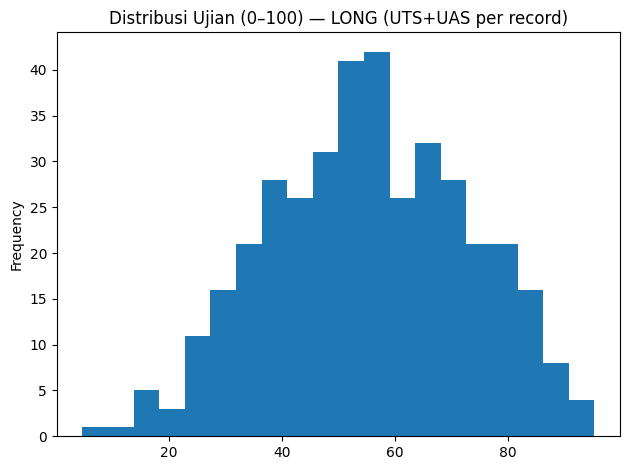

In [ ]:
df_dedup["Ujian_0_100"] = pd.to_numeric(df_dedup["Nilai_Raw_Num"], errors="coerce")
df_dedup["Ujian_Method"] = np.where(df_dedup["Ujian_0_100"].notna(), "as_is_0_100", "non_numeric")

out_of_range = df_dedup["Ujian_0_100"].notna() & ((df_dedup["Ujian_0_100"] < 0) | (df_dedup["Ujian_0_100"] > 100))
df_dedup.loc[out_of_range, "Ujian_Method"] = "clipped_out_of_range"

# clip (supaya tetap bisa dipakai modeling) tapi semua kasus out_of_range dilaporkan
df_dedup.loc[df_dedup["Ujian_0_100"].notna(), "Ujian_0_100"] = df_dedup.loc[df_dedup["Ujian_0_100"].notna(), "Ujian_0_100"].clip(0, 100)

bad_scale = df_dedup[
    df_dedup["Ujian_0_100"].isna() | (df_dedup["Ujian_Method"] == "clipped_out_of_range")
].copy()

print("="*110)
print("AUDIT NILAI UJIAN (SUDAH 0–100) — UJIAN")
print("="*110)
print("Non-numeric (NaN):", int(df_dedup["Ujian_0_100"].isna().sum()))
print("Out-of-range (di-clip):", int(out_of_range.sum()))

print("\nRingkasan method:")
display(df_dedup["Ujian_Method"].value_counts(dropna=False).to_frame("Jumlah"))

if bad_scale.shape[0] > 0:
    print("\nContoh baris bermasalah (NaN atau out-of-range):")
    display(bad_scale[["NPM","Nama","Kelas","Jenis_Ujian","MK_Std","Nilai_Raw","Nilai_Raw_Num","Ujian_0_100","Ujian_Method"]].head(50))
    bad_scale.to_csv(OUT_BAD_SCALE, index=False)
    print("Report skala bermasalah tersimpan:", OUT_BAD_SCALE)

plt.figure()
df_dedup["Ujian_0_100"].dropna().plot(kind="hist", bins=20)
plt.title("Distribusi Ujian (0–100) — LONG (UTS+UAS per record)")
plt.tight_layout()
plt.show()


***CELL 15 — Bentuk LONG Clean (real semua UTS & UAS) + tampilkan dulu baru save***

In [ ]:
long_cols = [
    "NPM","Nama","Kelas","Mata_Kuliah","Jenis_Ujian",
    "MK_Std","Nilai_Raw_Num","Ujian_0_100","Ujian_Method"
]
df_long = df_dedup[long_cols].copy()

print("="*110)
print("BENTUK DATA LONG (BERSIH) — UJIAN — sebelum SAVE")
print("="*110)
print("Ukuran:", df_long.shape)
print("NPM unik:", df_long["NPM"].nunique())
print("MK_Std unik:", df_long["MK_Std"].nunique())
print("Jumlah record UTS:", int((df_long["Jenis_Ujian"]=="UTS").sum()))
print("Jumlah record UAS:", int((df_long["Jenis_Ujian"]=="UAS").sum()))
display(df_long.head(10))

df_long.to_csv(OUT_LONG_CLEAN, index=False)
print("LONG clean tersimpan:", OUT_LONG_CLEAN)

BENTUK DATA LONG (BERSIH) — UJIAN — sebelum SAVE
Ukuran: (472, 9)
NPM unik: 256
MK_Std unik: 7
Jumlah record UTS: 0
Jumlah record UAS: 0


,NPM,Nama,Kelas,Mata_Kuliah,Jenis_Ujian,MK_Std,Nilai_Raw_Num,Ujian_0_100,Ujian_Method
0,G1F022077,Ahmad Afif Nurdiantoro,Desain Basis Data,,,desain basis data,55.17,55.17,as_is_0_100
1,G1F023045,Ahmad Al Fikri,Desain Basis Data,,,desain basis data,51.72,51.72,as_is_0_100
2,G1F022005,Ahmad Fadhila,Desain Basis Data,,,desain basis data,62.07,62.07,as_is_0_100
3,G1F023005,AMMI SUMIYANA,Desain Basis Data,,,desain basis data,37.93,37.93,as_is_0_100
4,G1F023043,Anas Thasiya Astuti,Desain Basis Data,,,desain basis data,55.17,55.17,as_is_0_100
5,G1F023016,Andini Istiqomah,Desain Basis Data,,,desain basis data,75.86,75.86,as_is_0_100
6,G1F023047,Annisa Rizky Maulida,Desain Basis Data,,,desain basis data,75.86,75.86,as_is_0_100
7,G1F023017,Antanur Mantoyasiin,Desain Basis Data,,,desain basis data,51.72,51.72,as_is_0_100
8,G1F023022,arinta sekar jannati,Desain Basis Data,,,desain basis data,37.93,37.93,as_is_0_100
9,G1F023054,Bela Rizki Agustin,Desain Basis Data,,,desain basis data,72.41,72.41,as_is_0_100


LONG clean tersimpan: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Ujian/ujian_long_clean_2025.csv


***CELL 16 — FINAL AGREGASI ADIL (1 NPM = 1 NILAI)***

BENTUK DATA FINAL (WIDE) — UJIAN — sebelum SAVE
Ukuran: (168, 11)
Duplikasi NPM: 0


,NPM,Nama,MK_KDP,MK_PBO,MK_SBD,MK_STATPROB,MK_ITS,MK_KBD,MK_DBD,Jumlah_Record_Ujian,Ujian_Final_0_100
0,G1F021019,Fransiscus Juan Sebastian Wibowo,NaN,66.67,80.77,NaN,NaN,NaN,NaN,2,73.72
1,G1F021033,Septiawan,NaN,19.05,NaN,NaN,NaN,NaN,NaN,1,19.05
2,G1F021038,Fachrul Rozi Ramadhan,NaN,80.95,NaN,NaN,NaN,NaN,NaN,1,80.95
3,G1F021045,Ananda Naila Evril,NaN,NaN,NaN,57.14,NaN,NaN,NaN,1,57.14
4,G1F022002,Ulfa,NaN,NaN,NaN,NaN,48.0,NaN,NaN,1,48.00
5,G1F022005,Ahmad Fadhila,NaN,NaN,NaN,NaN,NaN,NaN,62.07,1,62.07
6,G1F022007,AHMAD DWICAHYADI,NaN,NaN,NaN,NaN,28.0,NaN,NaN,1,28.00
7,G1F022008,Meisy Dianita,NaN,NaN,NaN,NaN,84.0,NaN,NaN,1,84.00
8,G1F022010,Imam piro,NaN,NaN,NaN,NaN,NaN,NaN,34.48,1,34.48
9,G1F022013,ANNAS ZAM ZAM,NaN,NaN,NaN,NaN,64.0,NaN,NaN,1,64.00


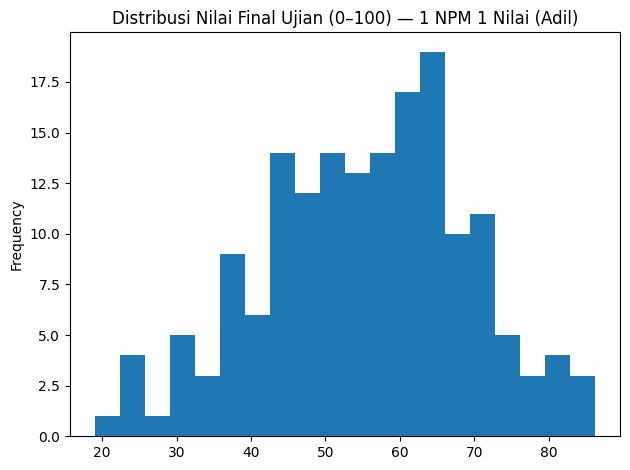

Final WIDE tersimpan: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Ujian/ujian_final_wide_1npm_1nilai_2025.csv


In [ ]:
# ============================================================
# CELL FINAL — AGREGASI ADIL (1 NPM = 1 NILAI)
# Output kolom:
# NPM | Nama | MK_* (nilai ujian 0-100 per MK) | Record Ujian | Ujian_Final_0_100
# Catatan fairness:
# (A) per mahasiswa-per MK: skor_MK = mean nilai ujian yg tersedia (UTS/UAS)
# (B) final mahasiswa = mean antar MK (tiap MK bobot sama)
# ============================================================

dfL = df_long.copy()

# pastikan numeric
dfL["Ujian_0_100"] = pd.to_numeric(dfL["Ujian_0_100"], errors="coerce")

# pastikan label UTS/UAS rapih (menghindari hitung 0-0)
dfL["Jenis_Ujian"] = dfL["Jenis_Ujian"].astype(str).str.strip().str.upper()

# hanya pakai record yang punya nilai ujian valid
dfL_valid = dfL[dfL["Ujian_0_100"].notna()].copy()

# ============================================================
# 1) Nama final per NPM (modus)
# ============================================================
name_mode = (
    dfL.groupby("NPM")["Nama"]
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
    .reset_index()
    .rename(columns={"Nama": "Nama"})
)

# ============================================================
# 2) Record counts (hanya dari nilai valid)
# ============================================================
rec = (
    dfL_valid.groupby("NPM", as_index=False)
    .agg(
        Jumlah_Record_Ujian=("Ujian_0_100", "count"),
        Jumlah_Record_UTS=("Jenis_Ujian", lambda s: int((s == "UTS").sum())),
        Jumlah_Record_UAS=("Jenis_Ujian", lambda s: int((s == "UAS").sum())),
    )
)

# ============================================================
# 3) (A) Skor per MK per mahasiswa = mean Ujian_0_100 (UTS/UAS yg tersedia)
# ============================================================
mk_per_npm = (
    dfL_valid.groupby(["NPM", "MK_Std"], as_index=False)
    .agg(Ujian_0_100_MK=("Ujian_0_100", "mean"))
)

# Pivot jadi kolom MK
pivot_mk = mk_per_npm.pivot(index="NPM", columns="MK_Std", values="Ujian_0_100_MK").reset_index()

# Pastikan 7 MK selalu ada kolomnya
for c in MK_STANDARDS:
    if c not in pivot_mk.columns:
        pivot_mk[c] = np.nan

# Rename ringkas kolom MK
mk_rename = {
    "komputer dan pemrograman": "MK_KDP",
    "pemrograman berorientasi objek": "MK_PBO",
    "sistem basis data": "MK_SBD",
    "statistika dan probabilitas": "MK_STATPROB",
    "intelligent tutoring system": "MK_ITS",
    "konsep basis data": "MK_KBD",
    "desain basis data": "MK_DBD",
}
pivot_mk = pivot_mk.rename(columns=mk_rename)

mk_cols_final = ["MK_KDP","MK_PBO","MK_SBD","MK_STATPROB","MK_ITS","MK_KBD","MK_DBD"]

# ============================================================
# 4) (B) Nilai final adil = mean antar MK (tiap MK bobot sama)
# ============================================================
pivot_mk["Ujian_Final_0_100"] = pivot_mk[mk_cols_final].mean(axis=1, skipna=True)

# ============================================================
# 5) Gabungkan: MK per mahasiswa + Nama + Record
# ============================================================
final_wide = (
    pivot_mk.merge(name_mode, on="NPM", how="left")
            .merge(rec, on="NPM", how="left")
)

# ============================================================
# 6) Susun kolom
# NPM | Nama | MK_* | Record | Ujian_Final_0_100
# ============================================================
final_wide = final_wide[
    ["NPM", "Nama"] + mk_cols_final +
    ["Jumlah_Record_Ujian", "Ujian_Final_0_100"]
].copy()

# ============================================================
# 7) Bulatkan skor 2 angka di belakang koma
# ============================================================
score_cols = mk_cols_final + ["Ujian_Final_0_100"]
final_wide[score_cols] = final_wide[score_cols].round(2)

# ============================================================
# 8) Tampilkan sebelum save
# ============================================================
print("="*110)
print("BENTUK DATA FINAL (WIDE) — UJIAN — sebelum SAVE")
print("="*110)
print("Ukuran:", final_wide.shape)
print("Duplikasi NPM:", int(final_wide["NPM"].duplicated().sum()))
display(final_wide.head(10))

plt.figure()
final_wide["Ujian_Final_0_100"].dropna().plot(kind="hist", bins=20)
plt.title("Distribusi Nilai Final Ujian (0–100) — 1 NPM 1 Nilai (Adil)")
plt.tight_layout()
plt.show()

# ============================================================
# 9) Save
# ============================================================
final_wide.to_csv(OUT_FINAL_WIDE, index=False)
print("Final WIDE tersimpan:", OUT_FINAL_WIDE)